<a href="https://colab.research.google.com/github/KatsayArtemDev/ml/blob/main/classification/predicting_heart_disease/heart_disease_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install scikit-learn matplotlib seaborn phik category_encoders optuna catboost xgboost lightgbm numpy<2.1 pandas==2.2.2 pillow<12.0

/bin/bash: line 1: 2.1: No such file or directory


In [ ]:
import sys

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import phik

import optuna

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, precision_recall_curve, make_scorer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, StackingClassifier

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

from IPython.display import display

pd.set_option('display.max_columns', None)

In [ ]:
RANDOM_STATE=42

In [ ]:
def get_df(path):
    return pd.read_csv(path, sep=',', decimal='.')

In [ ]:
train = get_df('./datasets/train.csv')

In [ ]:
display(train.head())
print()
train.info()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence



<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Heart Disease 

In [ ]:
int_cols = train.select_dtypes(include=['int64'])
float_cols = train.select_dtypes(include=['float64'])

for col in int_cols:
    train[col] = pd.to_numeric(train[col], downcast='integer')

for col in float_cols:
    train[col] = pd.to_numeric(train[col], downcast='float')

train.info()

<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int32  
 1   Age                      630000 non-null  int8   
 2   Sex                      630000 non-null  int8   
 3   Chest pain type          630000 non-null  int8   
 4   BP                       630000 non-null  int16  
 5   Cholesterol              630000 non-null  int16  
 6   FBS over 120             630000 non-null  int8   
 7   EKG results              630000 non-null  int8   
 8   Max HR                   630000 non-null  int16  
 9   Exercise angina          630000 non-null  int8   
 10  ST depression            630000 non-null  float32
 11  Slope of ST              630000 non-null  int8   
 12  Number of vessels fluro  630000 non-null  int8   
 13  Thallium                 630000 non-null  int8   
 14  Heart Disease  

In [ ]:
print('Явные дубликаты:', train.duplicated().sum())
train = train.drop_duplicates()

Явные дубликаты: 0


In [ ]:
train = train.drop(columns=['id'])

In [ ]:
eda_df = train.copy()

In [ ]:
target = 'Heart Disease'

y_desc = train[target].describe()
y_desc

count      630000
unique          2
top       Absence
freq       347546
Name: Heart Disease, dtype: object

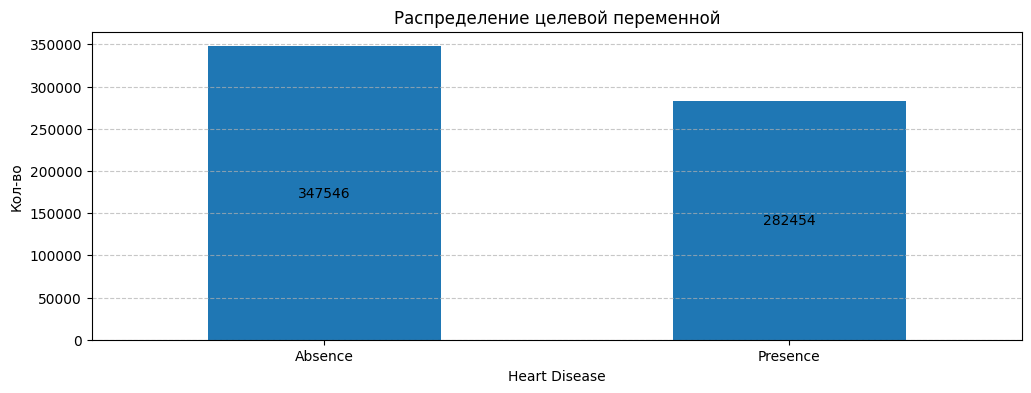

In [ ]:
y_counts = train[target].value_counts()

def show_bar(data, title):
    ax = data.plot(
        kind='bar',
        title=title,
        ylabel='Кол-во',
        rot=0,
        figsize=(12, 4)
    )

    ax.bar_label(ax.containers[0], label_type='center')
    ax.grid(axis='y', linestyle='--', alpha=.7)

    plt.show()
    plt.close()

show_bar(y_counts, 'Распределение целевой переменной')

In [ ]:
print(f'Доля Absence: {y_counts['Absence'] / y_desc['count'] * 100:.0f}%')
print(f'Доля Presence: {y_counts['Presence'] / y_desc['count'] * 100:.0f}%')

Доля Absence: 55%
Доля Presence: 45%


In [ ]:
data = []

num_cols = []
cat_cols = []
for col in eda_df.columns:
    if col == target:
        continue

    nu = eda_df[col].nunique()
    data.append({
        'Признак': col,
        'Кол-во': nu
    })

    if nu > 5:
        num_cols.append(col)
    else:
        cat_cols.append(col)

pd.DataFrame(data).sort_values('Кол-во', ascending=False)

,Признак,Кол-во
4,Cholesterol,150
7,Max HR,93
3,BP,66
9,ST depression,66
0,Age,42
11,Number of vessels fluro,4
2,Chest pain type,4
10,Slope of ST,3
6,EKG results,3
12,Thallium,3


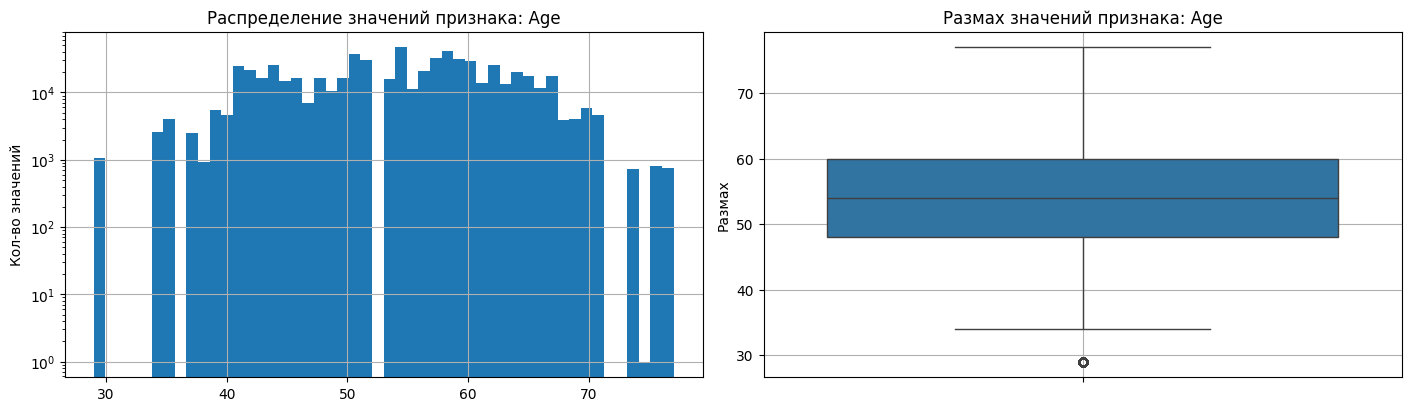

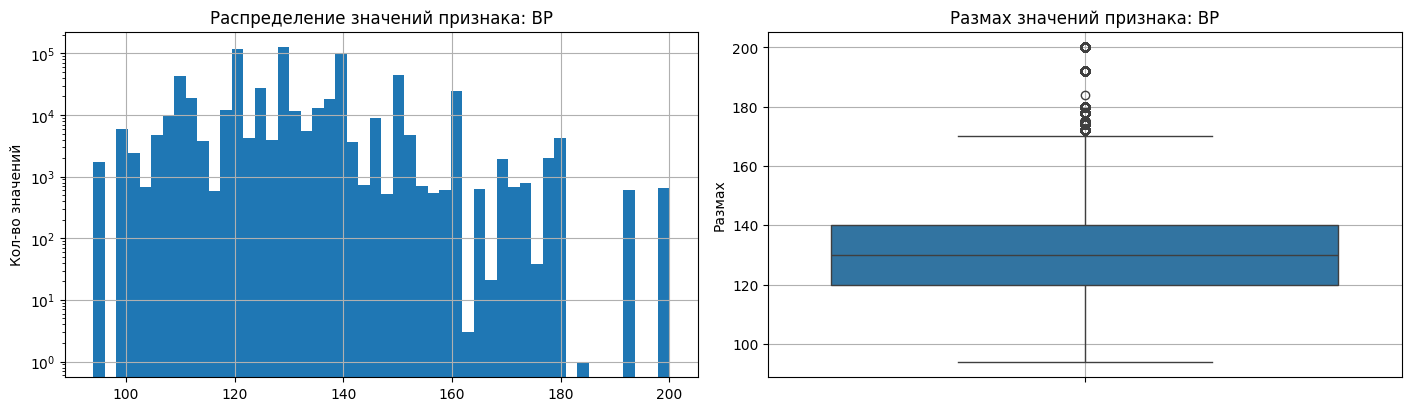

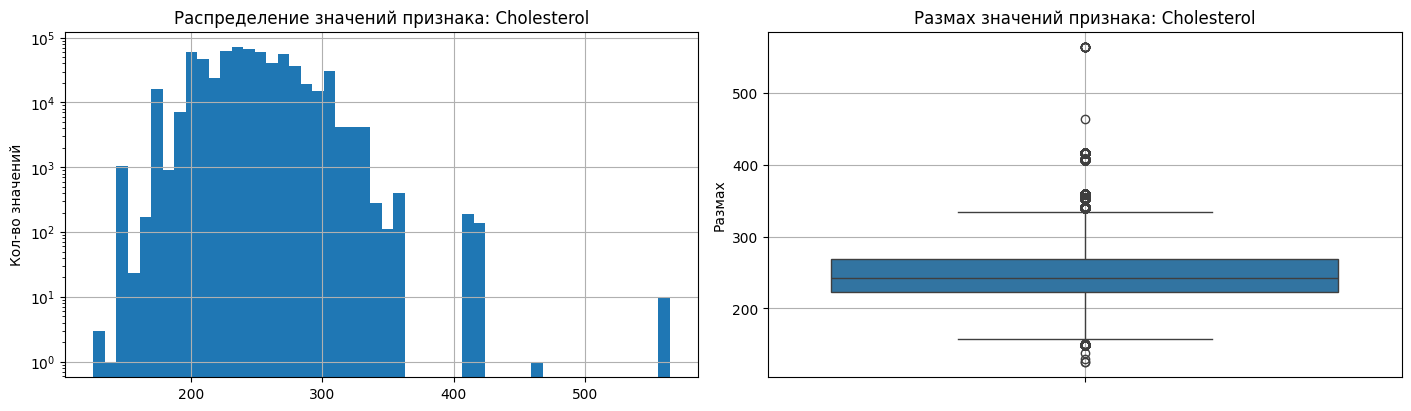

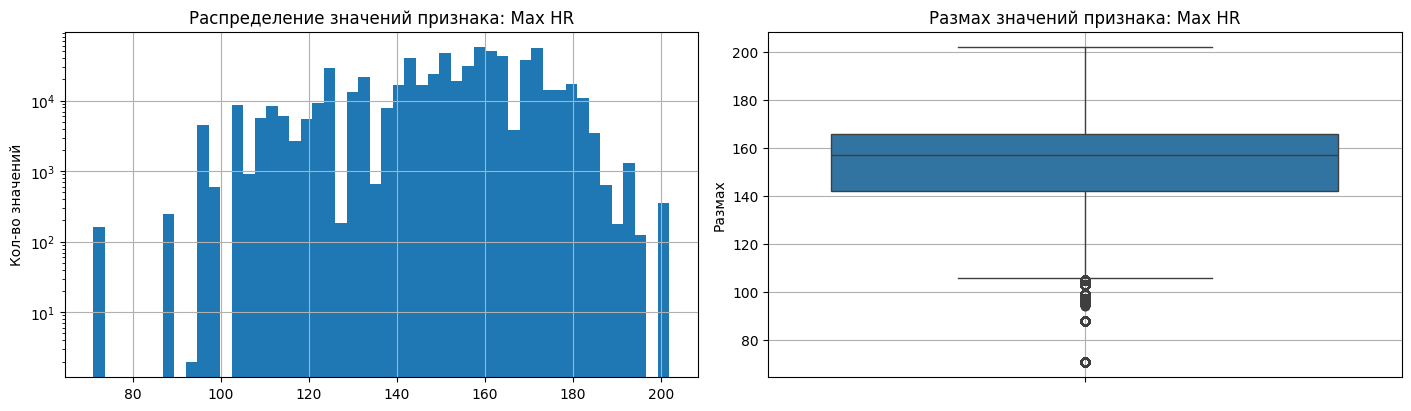

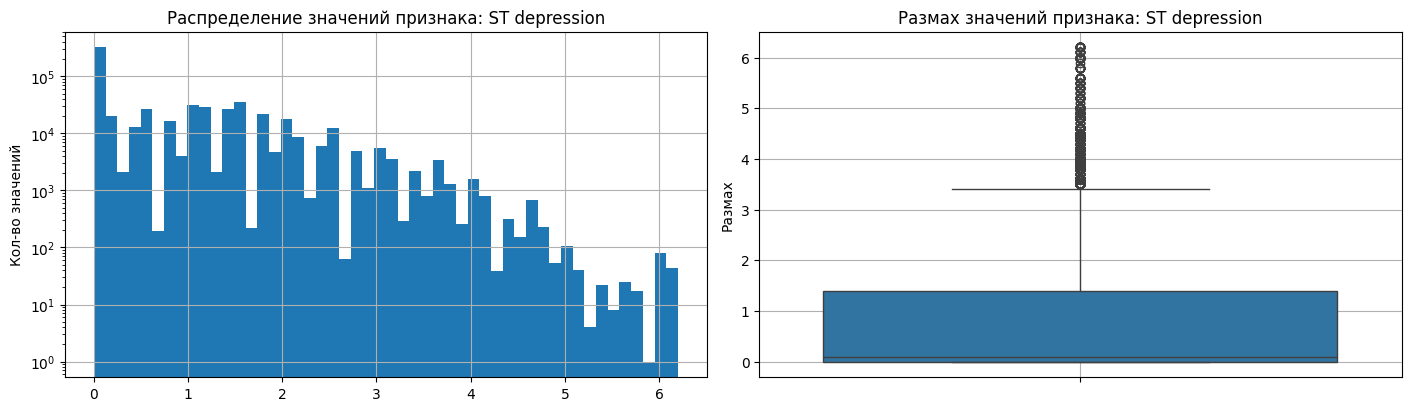

In [ ]:
def show_boxplot(col, data, ax):
    sns.boxplot(data=data, ax=ax)

    ax.set_title(f'Размах значений признака: {col}')
    ax.set_ylabel('Размах')
    ax.grid(True)

def show_hist(col, data, ax):
    data.plot(
        kind='hist',
        bins=50,
        grid=True,
        ax=ax
    )

    ax.set_title(f'Распределение значений признака: {col}')
    ax.set_ylabel('Кол-во значений')
    ax.set_yscale('log')

def show_hist(col, data, ax):
    data.plot(
        kind='hist',
        bins=50,
        grid=True,
        ax=ax
    )

    ax.set_title(f'Распределение значений признака: {col}')
    ax.set_ylabel('Кол-во значений')
    ax.set_yscale('log')

for col in num_cols:
    _, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 4), constrained_layout=True)

    data = eda_df[col]
    show_hist(col, data, axes[0])
    show_boxplot(col, data, axes[1])

    plt.show()
    plt.close()


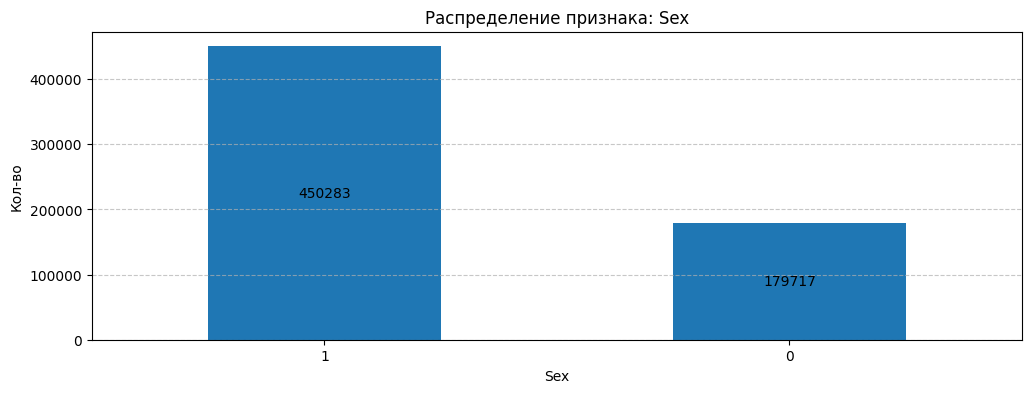

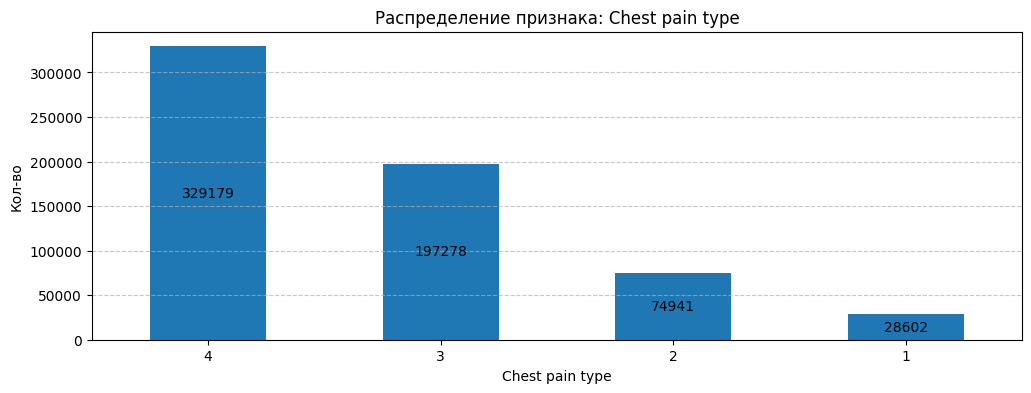

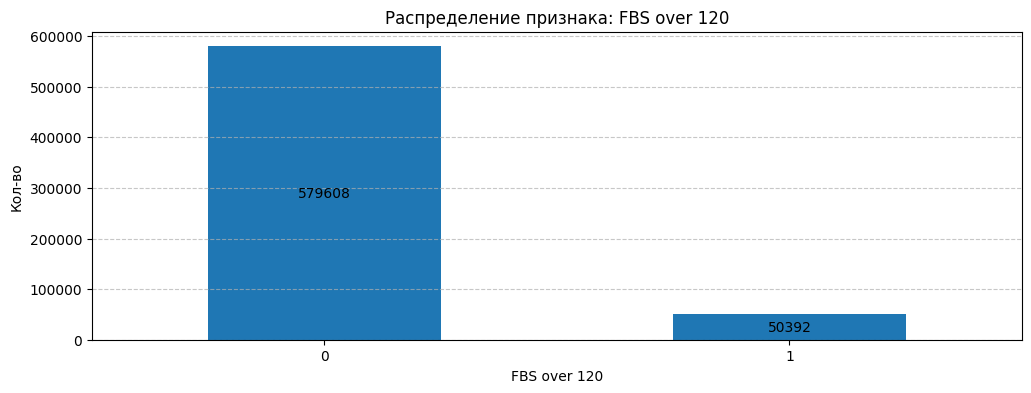

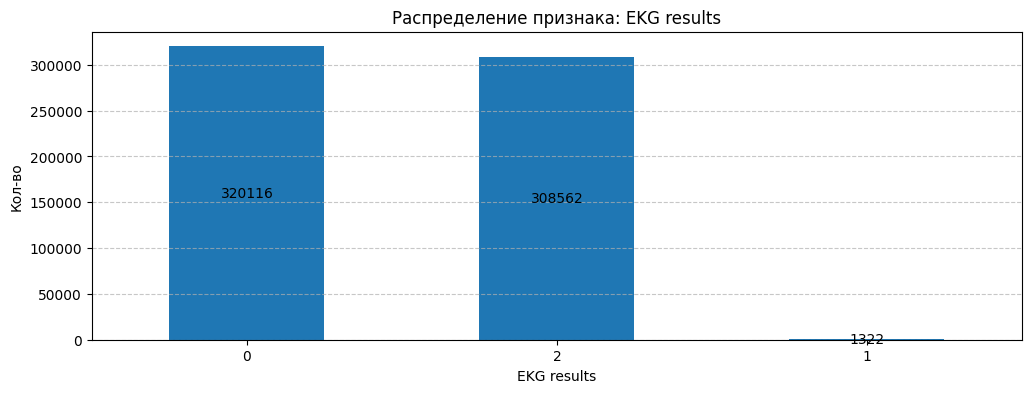

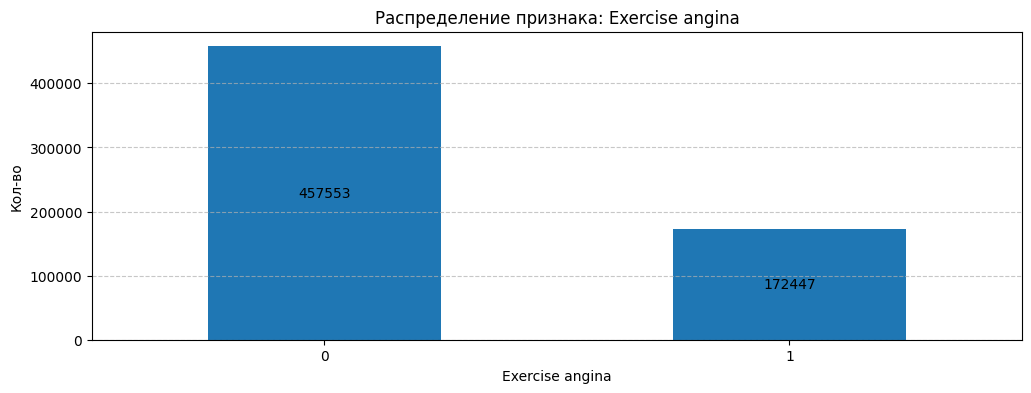

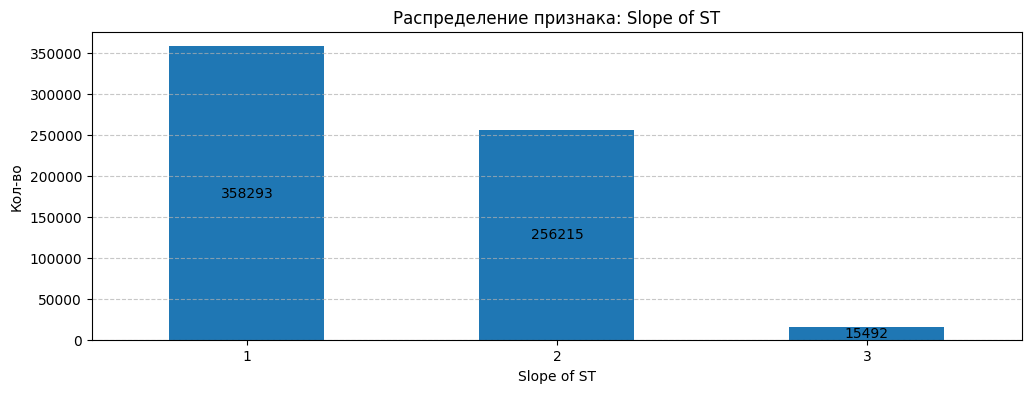

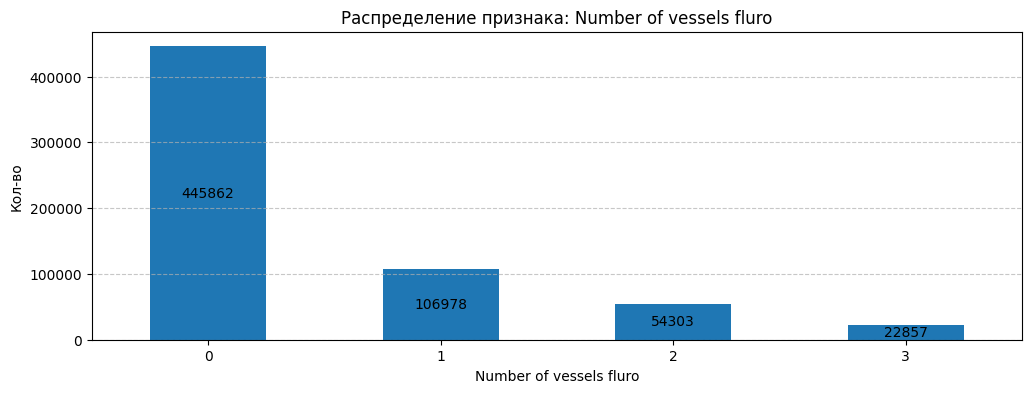

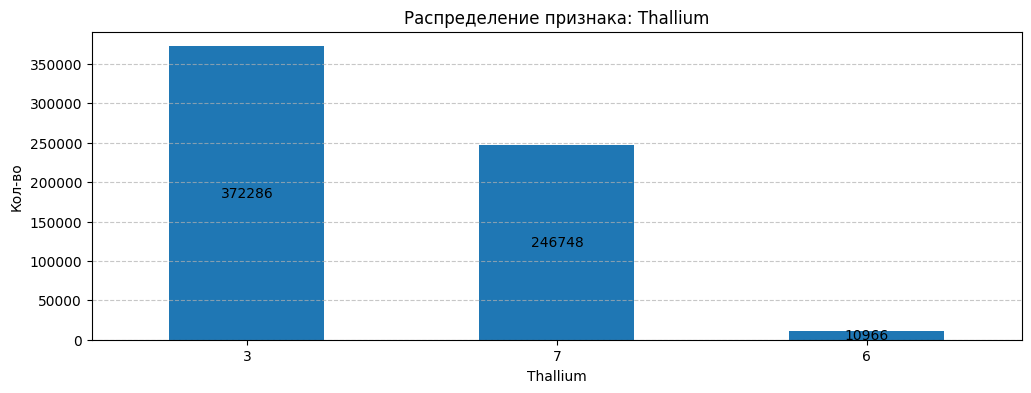

In [ ]:
for col in cat_cols:
    show_bar(eda_df[col].value_counts(), f'Распределение признака: {col}')

In [ ]:
def show_heatmap(corr, title, x, y_coef):
    num_rows = len(corr)
    dynamic_height = max(5, num_rows * y_coef)
    plt.figure(figsize=(x, dynamic_height))

    sns.heatmap(
        corr,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        linewidth=.5,
        cbar=False
    )

    plt.title(title)
    plt.show()

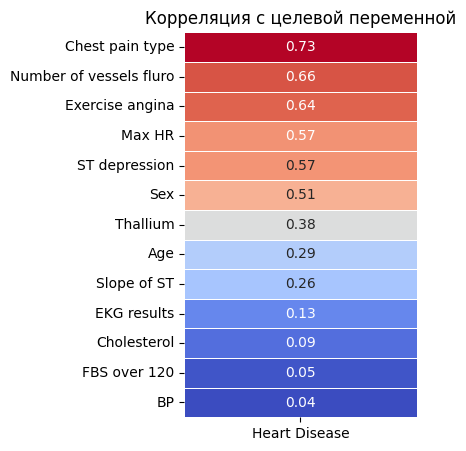

In [ ]:
corr_matrix = eda_df.phik_matrix(interval_cols=['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium'])
target_corr = corr_matrix[corr_matrix.index != 'Heart Disease'][['Heart Disease']].sort_values('Heart Disease', ascending=False)

show_heatmap(target_corr, title='Корреляция с целевой переменной', x=3, y_coef=.1)

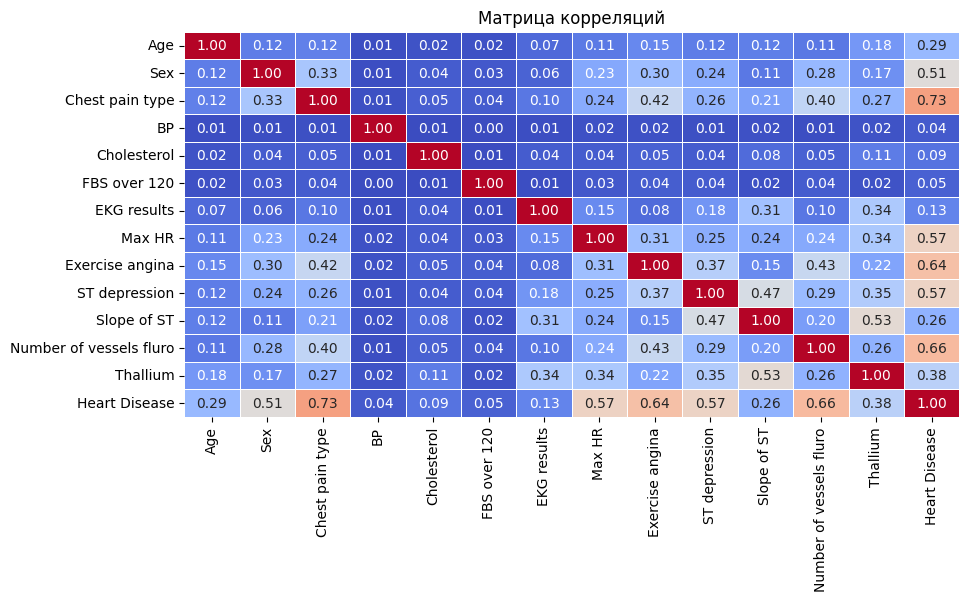

In [ ]:
show_heatmap(corr_matrix, title='Матрица корреляций', x=10, y_coef=.3)

In [ ]:
nominal_cols = ['Chest pain type', 'EKG results', 'Thallium', 'Slope of ST']

In [ ]:
mapping = {
    'Chest pain type': {
        1: 'Typical Angina', 2: 'Atypical Angina',
        3: 'Non-anginal Pain', 4: 'Asymptomatic'
    },
    'EKG results': {
        0: 'Normal', 1: 'ST-T Abnormality',
        2: 'LV Hypertrophy'
    },
    'Slope of ST': {
        1: 'Upsloping', 2: 'Flat', 3: 'Downsloping'
    },
    'Thallium': {
        3: 'Normal', 6: 'Fixed Defect', 7: 'Reversible Defect'
    }
}

for col, labels in mapping.items():
    if col in nominal_cols:
        eda_df[col] = eda_df[col].map(labels)

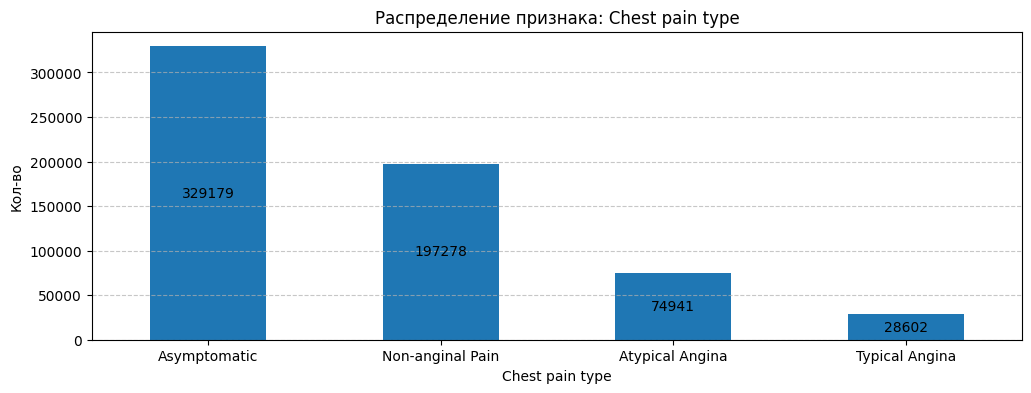

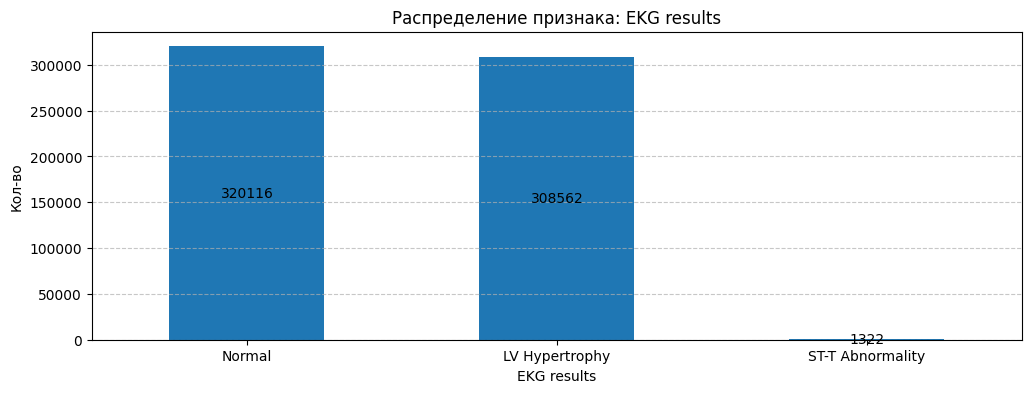

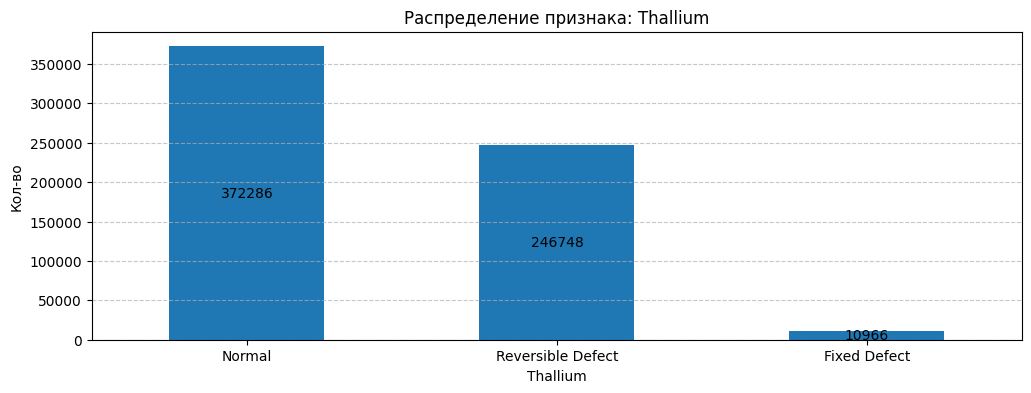

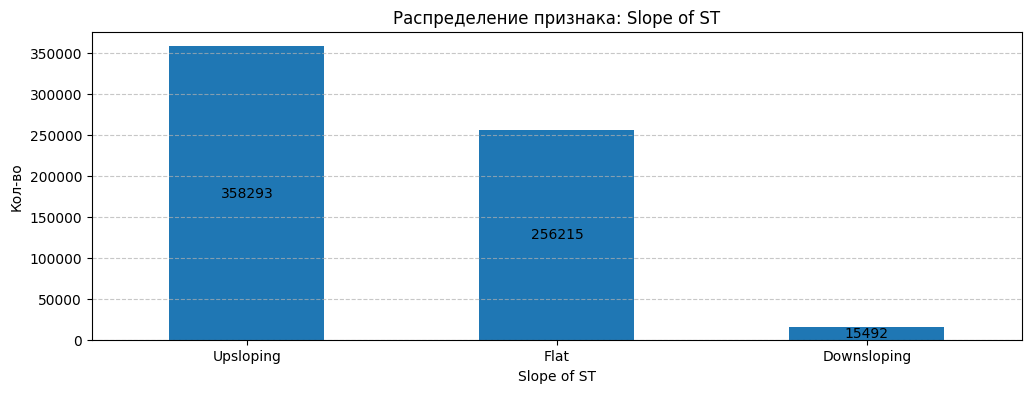

In [ ]:
for col in nominal_cols:
    show_bar(eda_df[col].value_counts(), f'Распределение признака: {col}')

In [ ]:
cols_to_log = ['ST depression', 'Cholesterol']

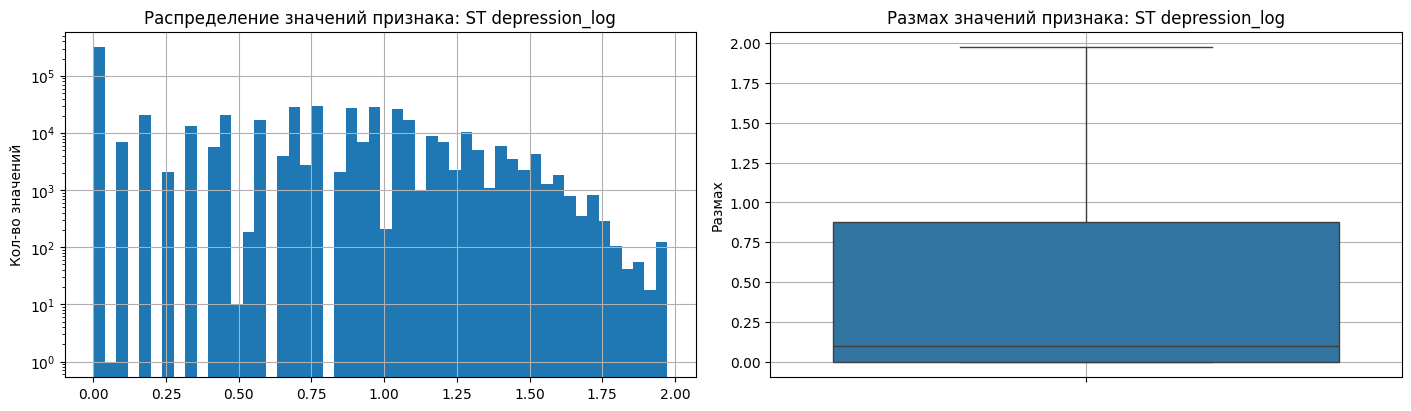

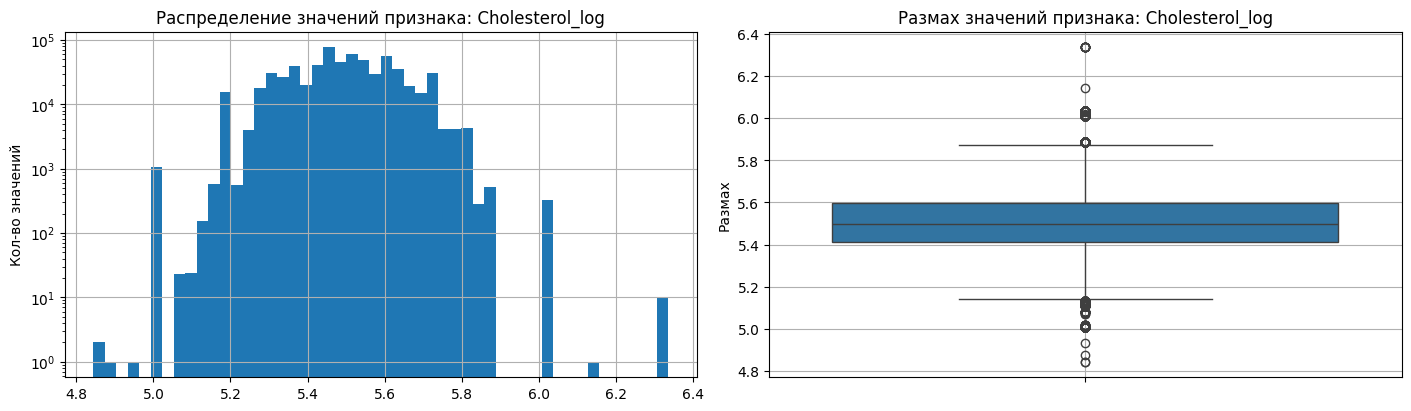

In [ ]:
log_col_names = [f'{col}_log' for col in cols_to_log]
eda_df[log_col_names] = eda_df[cols_to_log].apply(np.log1p)

for col in log_col_names:
    _, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 4), constrained_layout=True)

    data = eda_df[col]
    show_hist(col, data, axes[0])
    show_boxplot(col, data, axes[1])

    plt.show()
    plt.close()

In [ ]:
eda_df = eda_df.drop(columns=cols_to_log)

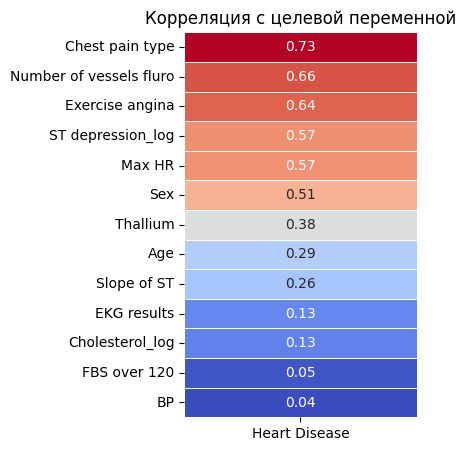

In [ ]:
corr_matrix = eda_df.phik_matrix(interval_cols=['Age', 'Sex', 'BP', 'FBS over 120', 'Max HR', 'Exercise angina', 'Number of vessels fluro', 'ST depression_log', 'Cholesterol_log'])
target_corr = corr_matrix[corr_matrix.index != 'Heart Disease'][['Heart Disease']].sort_values('Heart Disease', ascending=False)

show_heatmap(target_corr, title='Корреляция с целевой переменной', x=3, y_coef=.1)

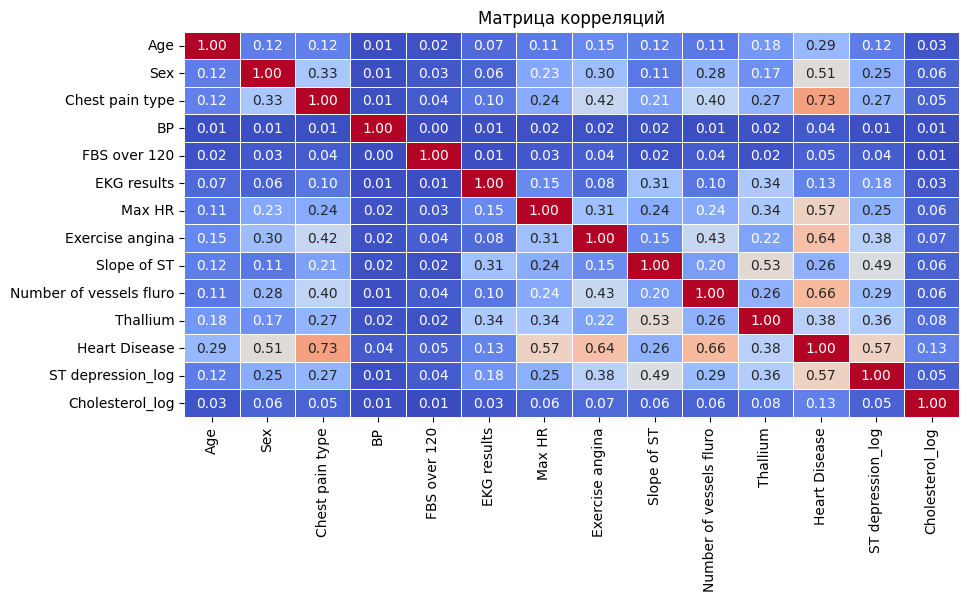

In [ ]:
show_heatmap(corr_matrix, title='Матрица корреляций', x=10, y_coef=.3)

In [ ]:
X = train.drop(columns=['Heart Disease'])
y = train['Heart Disease'].map({'Absence': 0, 'Presence': 1})

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X[:30000],
    y[:30000],
    stratify=y[:30000],
    shuffle=True,
    test_size=.2,
    random_state=RANDOM_STATE
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Среднее значенее целевой переменной в train: {y_train.mean():.3f}")
print(f"Среднее значенее целевой переменной в test: {y_test.mean():.3f}")

Размер обучающей выборки: (24000, 13)
Размер тестовой выборки: (6000, 13)
Среднее значенее целевой переменной в train: 0.449
Среднее значенее целевой переменной в test: 0.449


In [ ]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

In [ ]:
results = []

In [ ]:
def thresh_calc(y, y_proba):
    precisions, recalls, thresholds = precision_recall_curve(y, y_proba)

    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)

    best_idx = np.argmax(f1_scores[:-1])
    best_thresh = thresholds[best_idx]

    print(f"\nОптимальный порог: {best_thresh:.4f}")
    print(f"Максимальный F1-score: {f1_scores[best_idx]:.4f}\n")

    return (y_proba >= best_thresh).astype(int), best_thresh

def plot_classification_results(y_test, y_prob, y_pred, best_thresh, name="Model"):
    _, (ax_conf, ax_prob) = plt.subplots(1, 2, figsize=(16, 6))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_conf)
    ax_conf.set(
        title=f"{name} - Confusion Matrix",
        xlabel="Предсказанные метки",
        ylabel="Актуальные метки"
    )

    df_probs = pd.DataFrame({'Probability': y_prob, 'Actual': y_test})

    sns.histplot(data=df_probs, x='Probability', hue='Actual',
                 element='step', kde=True, bins=30, ax=ax_prob, palette='magma')

    ax_prob.axvline(best_thresh, color="red", linestyle="--", label=f'Порог {best_thresh:.2f}')
    ax_prob.set(
        title=f"{name} - Вероятностное распределение по классам",
        xlabel="Предполагаемая вероятность (1)",
        ylabel="Кол-во",
    )
    ax_prob.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

def show_ROC_curve(y_true, y_proba, score, name):
    fpr, tpr, _ = roc_curve(y_true, y_proba)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC-кривая (AUC = {score:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title(f'ROC-кривая: {name}')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.show()

def evaluate_model(pipeline, X_train, y_train, name="Model"):
    y_proba = cross_val_predict(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]
    score = roc_auc_score(y_train, y_proba)

    print(f"[{name}] ROC-AUC: {score:.4f}\n")
    show_ROC_curve(y_train, y_proba, score, name)

    y_pred, best_thresh = thresh_calc(y_train, y_proba)
    print("Результаты на тесте с новым порогом")
    print(classification_report(y_train, y_pred, zero_division=0))

    plot_classification_results(y_train, y_proba, y_pred, best_thresh, name)

    results.append({
        'Название модели': name,
        'ROC-AUC': score
    })

In [ ]:
def run_optuna(build_pipeline_fn, build_best_pipeline_fn, name):
    def objective(trial):
        pipeline = build_pipeline_fn(trial)

        scores = cross_val_score(
            pipeline,
            X_train,
            y_train,
            cv=cv,
            scoring="roc_auc",
            n_jobs=-1
        )

        mean_score = scores.mean()

        trial.report(mean_score, step=0)
        if trial.should_prune():
            raise optuna.TrialPruned()

        return mean_score

    sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
    study = optuna.create_study(direction='maximize', sampler=sampler)
    study.optimize(objective, n_trials=10, show_progress_bar=True, n_jobs=1)

    fig1 = optuna.visualization.plot_optimization_history(study)
    fig2 = optuna.visualization.plot_param_importances(study)

    display(fig1)
    display(fig2)

    best_params = study.best_params
    print("Лучшие гиперпараметры:", best_params)
    best_value = study.best_value
    print("Лучшее среднее значение ROC-AUC на кросс-валидации:", round(best_value, 3))

    evaluate_model(build_best_pipeline_fn(best_params), X_train, y_train, name=name)

In [ ]:
base_linear_pipeline = Pipeline(steps=[
    ('preprocessor', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE))
])

[LogisticRegression [Baseline]] ROC-AUC: 0.9521



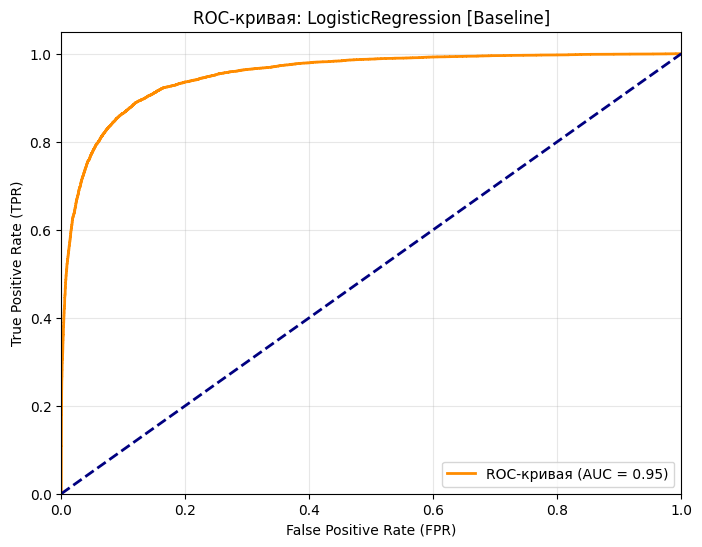


Оптимальный порог: 0.4615
Максимальный F1-score: 0.8731

Результаты на тесте с новым порогом
              precision    recall  f1-score   support

           0       0.91      0.88      0.89     13232
           1       0.86      0.89      0.87     10768

    accuracy                           0.88     24000
   macro avg       0.88      0.88      0.88     24000
weighted avg       0.88      0.88      0.88     24000



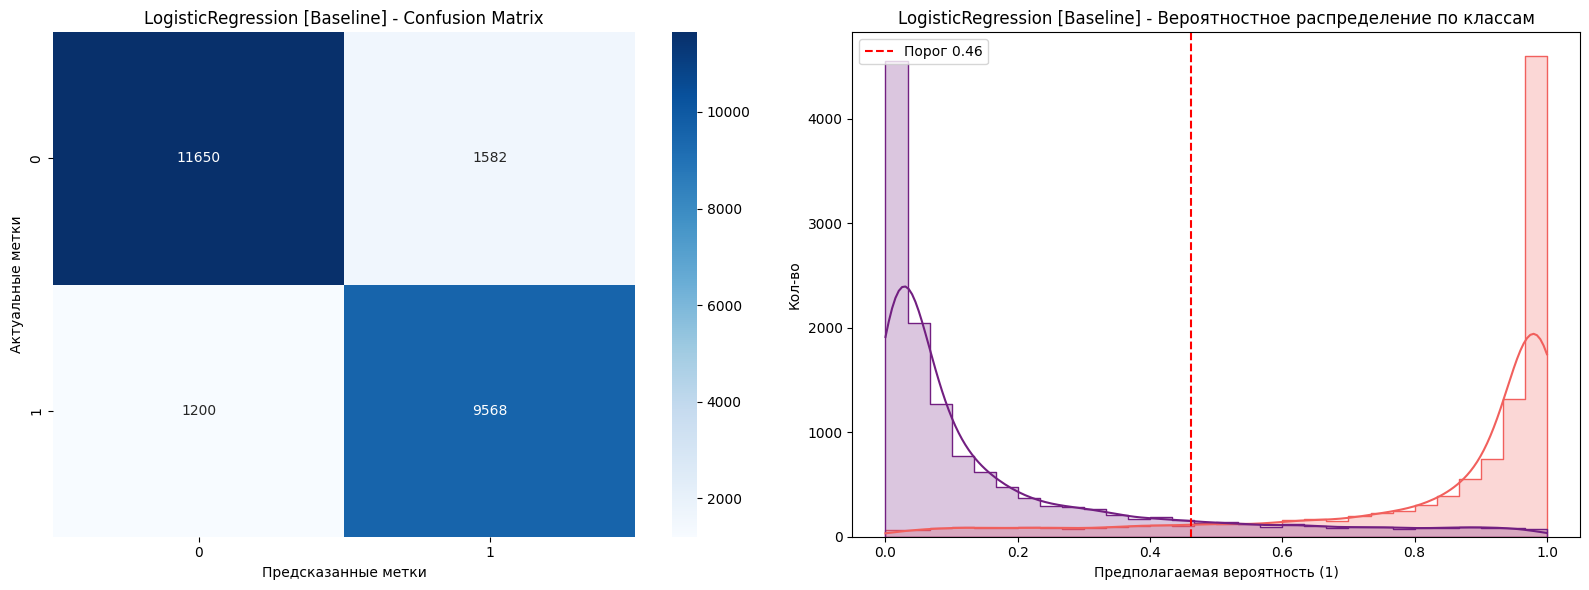

In [ ]:
evaluate_model(base_linear_pipeline, X_train, y_train, name='LogisticRegression [Baseline]')

In [ ]:
upd_num_cols = [col for col in num_cols if col not in cols_to_log + cat_cols]

In [ ]:
def medical_mapping_transformer(X):
    X_copy = X.copy()

    for col, labels in mapping.items():
        if col in X_copy.columns:
            X_copy[col] = X_copy[col].map(labels)

    return X_copy

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', make_pipeline(
            FunctionTransformer(medical_mapping_transformer, feature_names_out="one-to-one"),
            OneHotEncoder(drop='first', sparse_output=False)
        ), nominal_cols),
        ('log', make_pipeline(
            FunctionTransformer(np.log1p, feature_names_out="one-to-one"),
            StandardScaler()
        ), cols_to_log),
        ('num', StandardScaler(), upd_num_cols)
    ]
).set_output(transform="pandas")

X_transformed_df = preprocessor.fit_transform(X_train)
X_transformed_df.head()

,cat__Chest pain type_Atypical Angina,cat__Chest pain type_Non-anginal Pain,cat__Chest pain type_Typical Angina,cat__EKG results_Normal,cat__EKG results_ST-T Abnormality,cat__Thallium_Normal,cat__Thallium_Reversible Defect,cat__Slope of ST_Flat,cat__Slope of ST_Upsloping,log__ST depression,log__Cholesterol,num__Age,num__BP,num__Max HR
14487,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,-0.852335,0.751989,0.344275,-0.705209,-0.254240
12261,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,2.435413,0.391078,0.825644,-0.571746,-2.134159
9436,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.958801,-0.294634,-2.303258,-0.705209,0.215740
24339,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,-0.852335,0.886193,0.464617,-0.705209,-2.290819
12821,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,-0.852335,0.100807,-1.701546,-0.037895,0.476840


[LogisticRegression [Baseline with upd pipe]] ROC-AUC: 0.9383



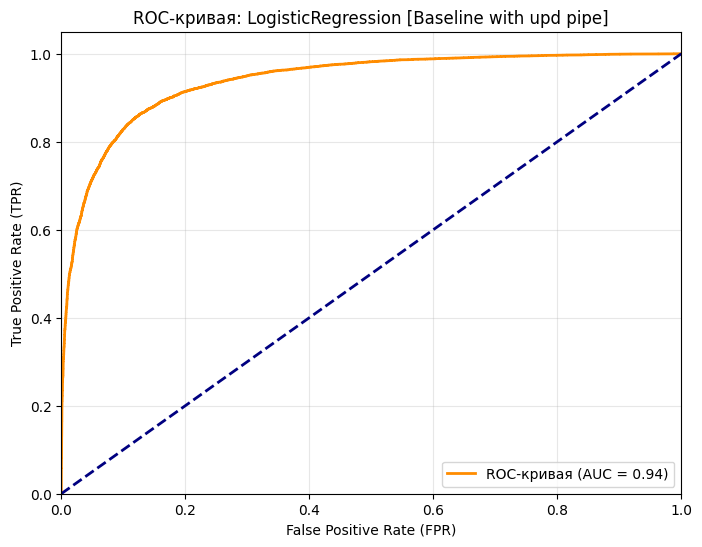


Оптимальный порог: 0.4954
Максимальный F1-score: 0.8549

Результаты на тесте с новым порогом
              precision    recall  f1-score   support

           0       0.89      0.87      0.88     13232
           1       0.85      0.86      0.85     10768

    accuracy                           0.87     24000
   macro avg       0.87      0.87      0.87     24000
weighted avg       0.87      0.87      0.87     24000



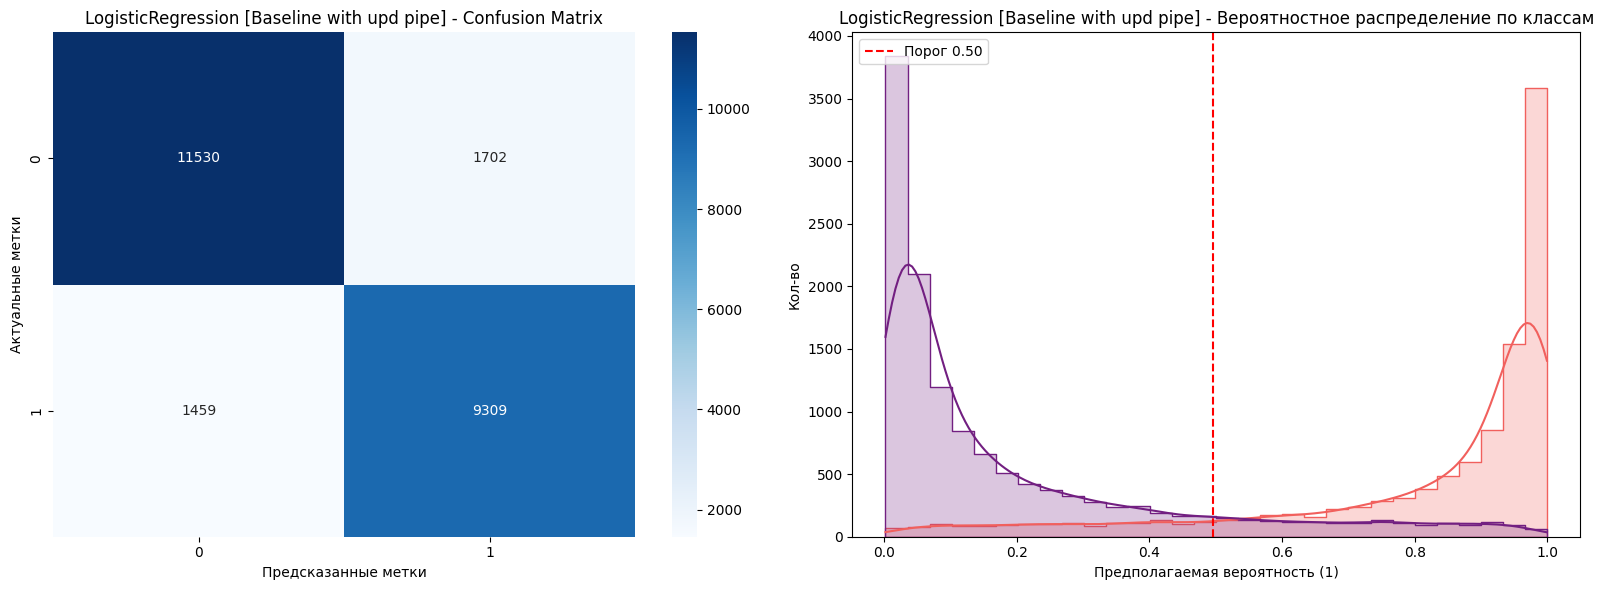

In [ ]:
upd_linear_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE))
])

evaluate_model(upd_linear_pipeline, X_train, y_train, name='LogisticRegression [Baseline with upd pipe]')

[I 2026-02-14 21:38:46,600] A new study created in memory with name: no-name-fa21a237-ec5c-4a2d-ba73-b0473173fc42


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-02-14 21:38:47,542] Trial 0 finished with value: 0.9521841915321092 and parameters: {'class_weight': 'balanced', 'tol': 0.0029106359131330704, 'max_iter': 12776, 'solver': 'saga', 'C': 0.4042872735027334, 'l1_ratio': 0.7080725777960455}. Best is trial 0 with value: 0.9521841915321092.
[I 2026-02-14 21:38:48,365] Trial 1 finished with value: 0.9521808234753413 and parameters: {'class_weight': 'balanced', 'tol': 0.004622589001020831, 'max_iter': 5822, 'solver': 'saga', 'C': 0.039054412752107935, 'l1_ratio': 0.2912291401980419}. Best is trial 0 with value: 0.9521841915321092.
[I 2026-02-14 21:38:48,754] Trial 2 finished with value: 0.9521787872664362 and parameters: {'class_weight': None, 'tol': 0.0003839629299804173, 'max_iter': 8594, 'solver': 'newton-cg', 'C': 0.35849855803404745}. Best is trial 0 with value: 0.9521841915321092.
[I 2026-02-14 21:38:49,171] Trial 3 finished with value: 0.9514409355464212 and parameters: {'class_weight': 'balanced', 'tol': 0.00021930485556643703,

Лучшие гиперпараметры: {'class_weight': 'balanced', 'tol': 0.0004470608546778491, 'max_iter': 15133, 'solver': 'newton-cg', 'C': 1.9031311745086963}
Лучшее среднее значение ROC-AUC на кросс-валидации: 0.952
[LogisticRegression [Best Params]] ROC-AUC: 0.9521



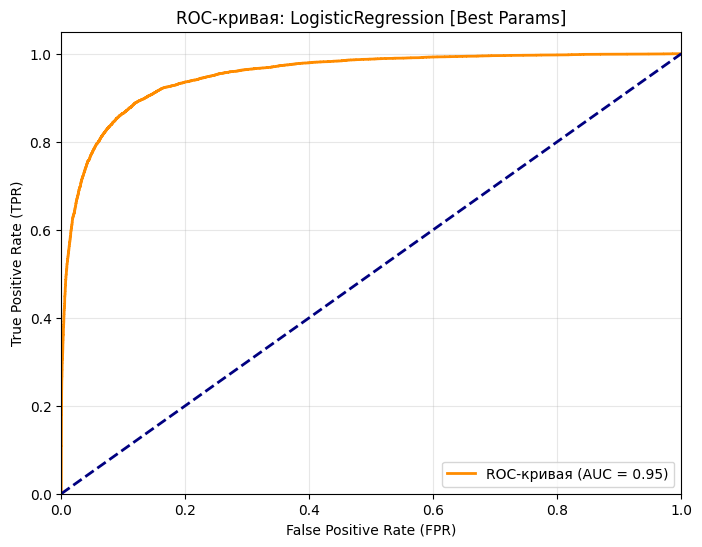


Оптимальный порог: 0.4603
Максимальный F1-score: 0.8731

Результаты на тесте с новым порогом
              precision    recall  f1-score   support

           0       0.91      0.88      0.89     13232
           1       0.86      0.89      0.87     10768

    accuracy                           0.88     24000
   macro avg       0.88      0.88      0.88     24000
weighted avg       0.88      0.88      0.88     24000



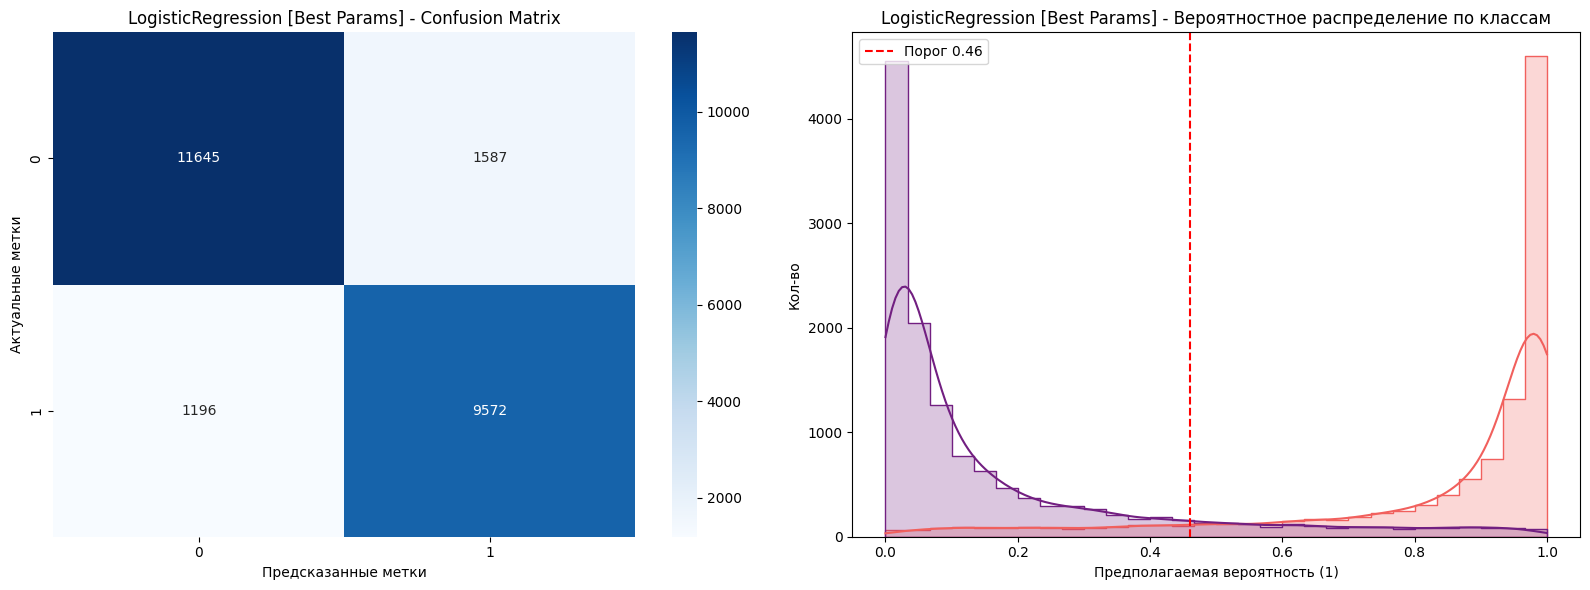

In [ ]:
def build_pipeline_fn(trial):
    params = {
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
        "fit_intercept": True,
        "tol": trial.suggest_float("tol", 1e-4, 1e-2, log=True),
        "max_iter": trial.suggest_int("max_iter", 2000, 20000),
        "solver": trial.suggest_categorical("solver", ["lbfgs", "newton-cg", "newton-cholesky", "saga"]),
        "C": trial.suggest_float("C", 1e-4, 1e2, log=True),
        "random_state": RANDOM_STATE,
    }

    solver = params["solver"]
    if solver in ["lbfgs", "newton-cg", "newton-cholesky"]:
        params["l1_ratio"] = 0
    elif solver == "saga":
        params["l1_ratio"] = trial.suggest_float("l1_ratio", 0.0, 1.0)

    model = LogisticRegression(**params)
    pipeline = Pipeline(steps=[
        ('preprocessor', StandardScaler()),
        ('model', model)
    ])

    return pipeline

def build_best_pipeline_fn(best_params):
    pipeline = Pipeline(steps=[
        ("preprocessor", StandardScaler()),
        ("model", LogisticRegression(**best_params, random_state=RANDOM_STATE, n_jobs=-1))
    ])
    return pipeline

run_optuna(build_pipeline_fn, build_best_pipeline_fn, "LogisticRegression [Best Params]")

[I 2026-02-14 21:38:56,962] A new study created in memory with name: no-name-3a277e12-9167-48fa-bb9e-183668fd8e7e


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-02-14 21:38:58,886] Trial 0 finished with value: 0.9384050067152533 and parameters: {'class_weight': 'balanced', 'tol': 0.0029106359131330704, 'max_iter': 12776, 'solver': 'saga', 'C': 0.4042872735027334, 'l1_ratio': 0.7080725777960455}. Best is trial 0 with value: 0.9384050067152533.
[I 2026-02-14 21:39:00,399] Trial 1 finished with value: 0.937989167758755 and parameters: {'class_weight': 'balanced', 'tol': 0.004622589001020831, 'max_iter': 5822, 'solver': 'saga', 'C': 0.039054412752107935, 'l1_ratio': 0.2912291401980419}. Best is trial 0 with value: 0.9384050067152533.
[I 2026-02-14 21:39:01,744] Trial 2 finished with value: 0.938365704765775 and parameters: {'class_weight': None, 'tol': 0.0003839629299804173, 'max_iter': 8594, 'solver': 'newton-cg', 'C': 0.35849855803404745}. Best is trial 0 with value: 0.9384050067152533.
[I 2026-02-14 21:39:02,924] Trial 3 finished with value: 0.9229373357203645 and parameters: {'class_weight': 'balanced', 'tol': 0.00021930485556643703, '

Лучшие гиперпараметры: {'class_weight': 'balanced', 'tol': 0.0029106359131330704, 'max_iter': 12776, 'solver': 'saga', 'C': 0.4042872735027334, 'l1_ratio': 0.7080725777960455}
Лучшее среднее значение ROC-AUC на кросс-валидации: 0.938
[LogisticRegression [Best Params with upd pipe]] ROC-AUC: 0.9383



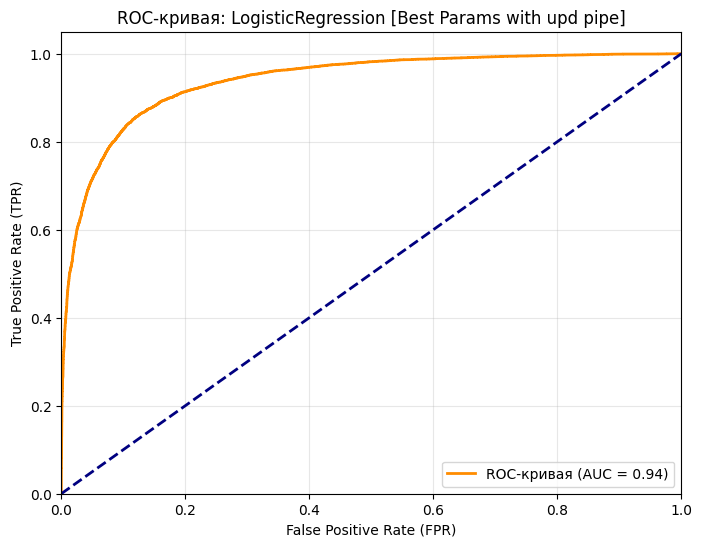


Оптимальный порог: 0.4983
Максимальный F1-score: 0.8548

Результаты на тесте с новым порогом
              precision    recall  f1-score   support

           0       0.89      0.87      0.88     13232
           1       0.85      0.86      0.85     10768

    accuracy                           0.87     24000
   macro avg       0.87      0.87      0.87     24000
weighted avg       0.87      0.87      0.87     24000



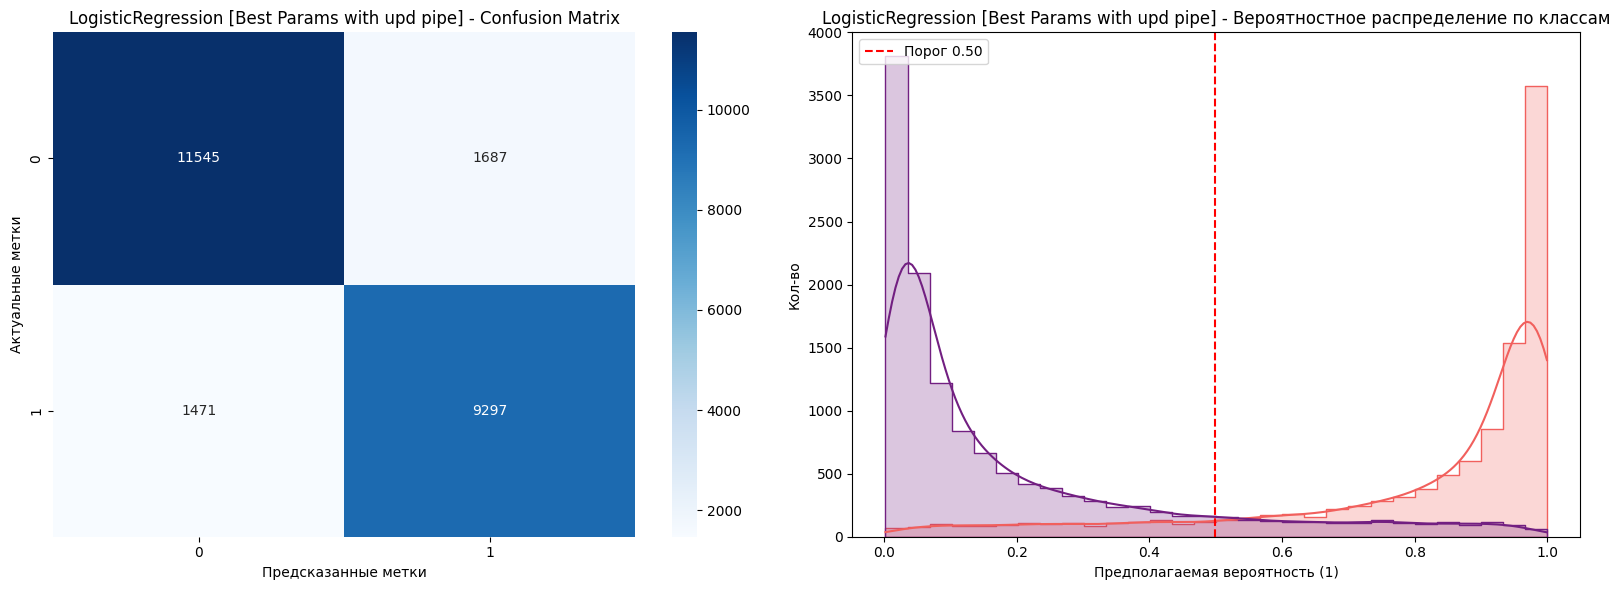

In [ ]:
def build_pipeline_fn(trial):
    params = {
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
        "fit_intercept": True,
        "tol": trial.suggest_float("tol", 1e-4, 1e-2, log=True),
        "max_iter": trial.suggest_int("max_iter", 2000, 20000),
        "solver": trial.suggest_categorical("solver", ["lbfgs", "newton-cg", "newton-cholesky", "saga"]),
        "C": trial.suggest_float("C", 1e-4, 1e2, log=True),
        "random_state": RANDOM_STATE,
    }

    solver = params["solver"]
    if solver in ["lbfgs", "newton-cg", "newton-cholesky"]:
        params["l1_ratio"] = 0
    elif solver == "saga":
        params["l1_ratio"] = trial.suggest_float("l1_ratio", 0.0, 1.0)

    model = LogisticRegression(**params)
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    return pipeline

def build_best_pipeline_fn(best_params):
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(**best_params, random_state=RANDOM_STATE, n_jobs=-1))
    ])
    return pipeline

run_optuna(build_pipeline_fn, build_best_pipeline_fn, "LogisticRegression [Best Params with upd pipe]")

[KNN [Baseline]] ROC-AUC: 0.9235



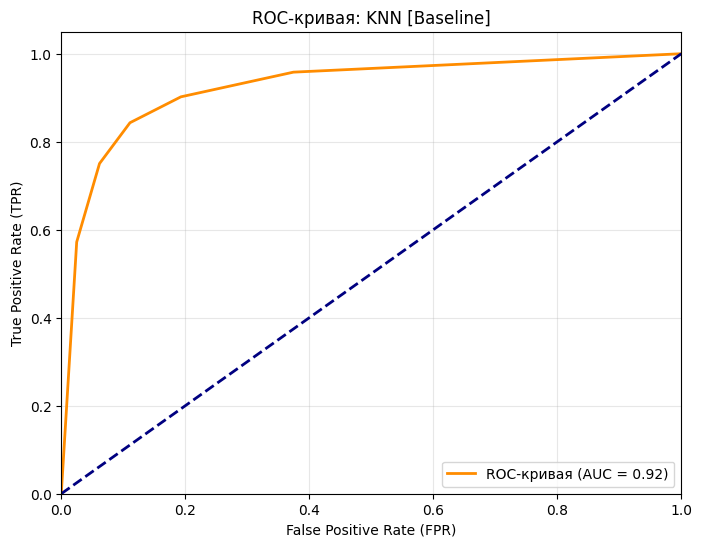


Оптимальный порог: 0.6000
Максимальный F1-score: 0.8520

Результаты на тесте с новым порогом
              precision    recall  f1-score   support

           0       0.87      0.89      0.88     13232
           1       0.86      0.84      0.85     10768

    accuracy                           0.87     24000
   macro avg       0.87      0.87      0.87     24000
weighted avg       0.87      0.87      0.87     24000



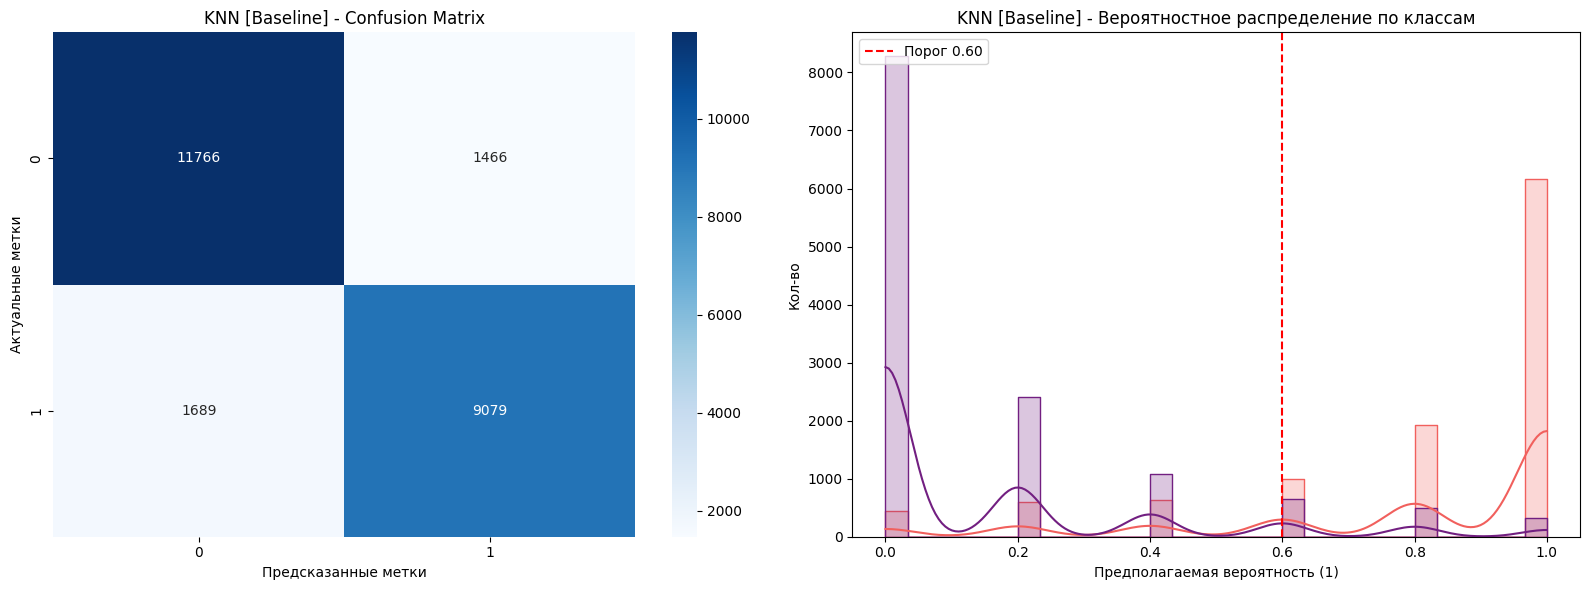

In [ ]:
base_knn_pipeline = Pipeline(steps=[
    ('preprocessor', StandardScaler()),
    ('model', KNeighborsClassifier())
])

evaluate_model(base_knn_pipeline, X_train, y_train, name='KNN [Baseline]')

[KNN [Baseline with upd pipe]] ROC-AUC: 0.9025



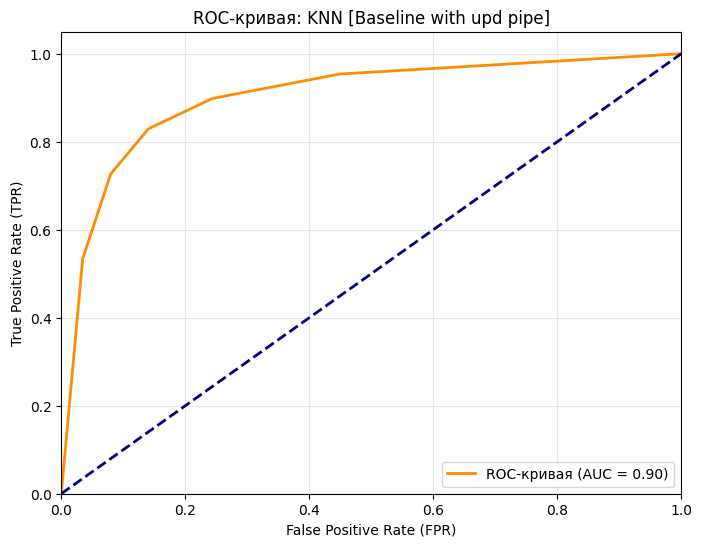


Оптимальный порог: 0.6000
Максимальный F1-score: 0.8285

Результаты на тесте с новым порогом
              precision    recall  f1-score   support

           0       0.86      0.86      0.86     13232
           1       0.83      0.83      0.83     10768

    accuracy                           0.85     24000
   macro avg       0.84      0.84      0.84     24000
weighted avg       0.85      0.85      0.85     24000



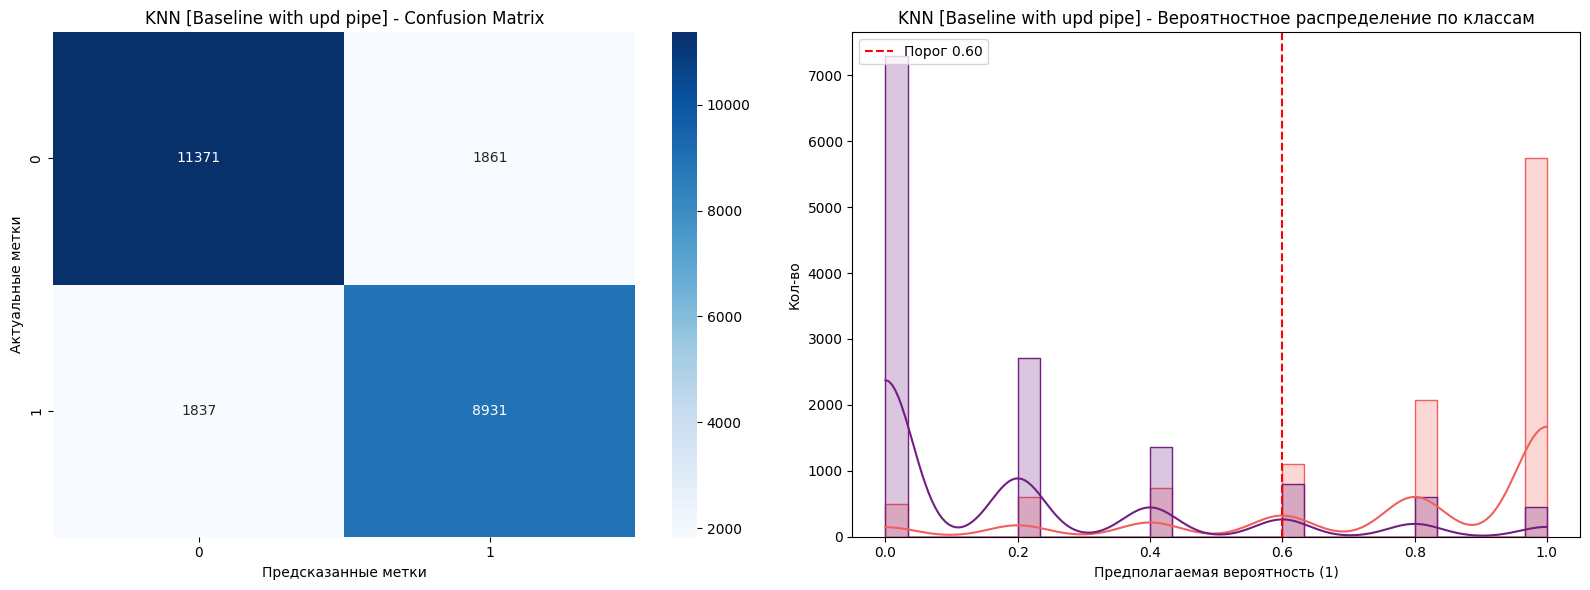

In [ ]:
upd_knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier())
])

evaluate_model(upd_knn_pipeline, X_train, y_train, name='KNN [Baseline with upd pipe]')

[I 2026-02-14 21:39:27,105] A new study created in memory with name: no-name-af5a2c46-4a97-4426-bcba-c1970d1c3dfe


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-02-14 21:39:42,111] Trial 0 finished with value: 0.9478330513486647 and parameters: {'n_neighbors': 188, 'weights': 'uniform', 'algorithm': 'auto', 'leaf_size': 175, 'metric': 'euclidean'}. Best is trial 0 with value: 0.9478330513486647.
[I 2026-02-14 21:39:51,403] Trial 1 finished with value: 0.9475766892770509 and parameters: {'n_neighbors': 485, 'weights': 'uniform', 'algorithm': 'brute', 'leaf_size': 92, 'metric': 'euclidean'}. Best is trial 0 with value: 0.9478330513486647.
[I 2026-02-14 21:41:46,876] Trial 2 finished with value: 0.9409680928456499 and parameters: {'n_neighbors': 147, 'weights': 'distance', 'algorithm': 'auto', 'leaf_size': 18, 'metric': 'minkowski', 'p': 5.7444276862666666}. Best is trial 0 with value: 0.9478330513486647.
[I 2026-02-14 21:42:14,214] Trial 3 finished with value: 0.9475827950625255 and parameters: {'n_neighbors': 483, 'weights': 'uniform', 'algorithm': 'ball_tree', 'leaf_size': 104, 'metric': 'euclidean'}. Best is trial 0 with value: 0.9478

Лучшие гиперпараметры: {'n_neighbors': 332, 'weights': 'distance', 'algorithm': 'kd_tree', 'leaf_size': 189, 'metric': 'manhattan'}
Лучшее среднее значение ROC-AUC на кросс-валидации: 0.95
[KNN [Best Params]] ROC-AUC: 0.9502



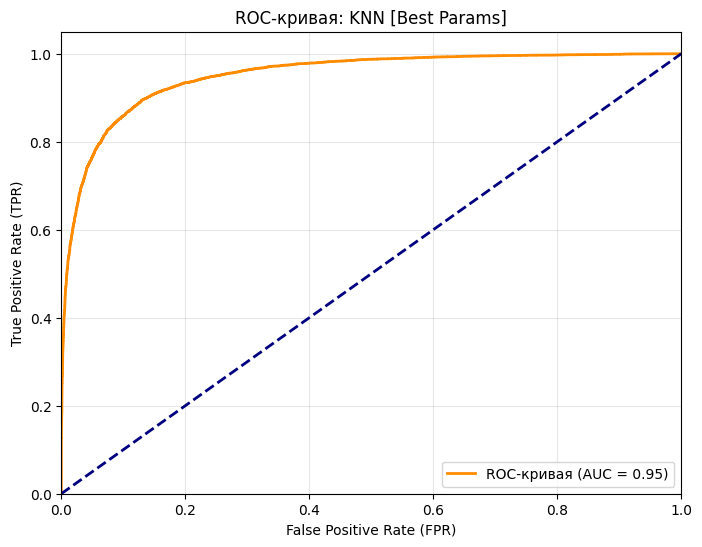


Оптимальный порог: 0.3346
Максимальный F1-score: 0.8708

Результаты на тесте с новым порогом
              precision    recall  f1-score   support

           0       0.91      0.87      0.89     13232
           1       0.85      0.89      0.87     10768

    accuracy                           0.88     24000
   macro avg       0.88      0.88      0.88     24000
weighted avg       0.88      0.88      0.88     24000



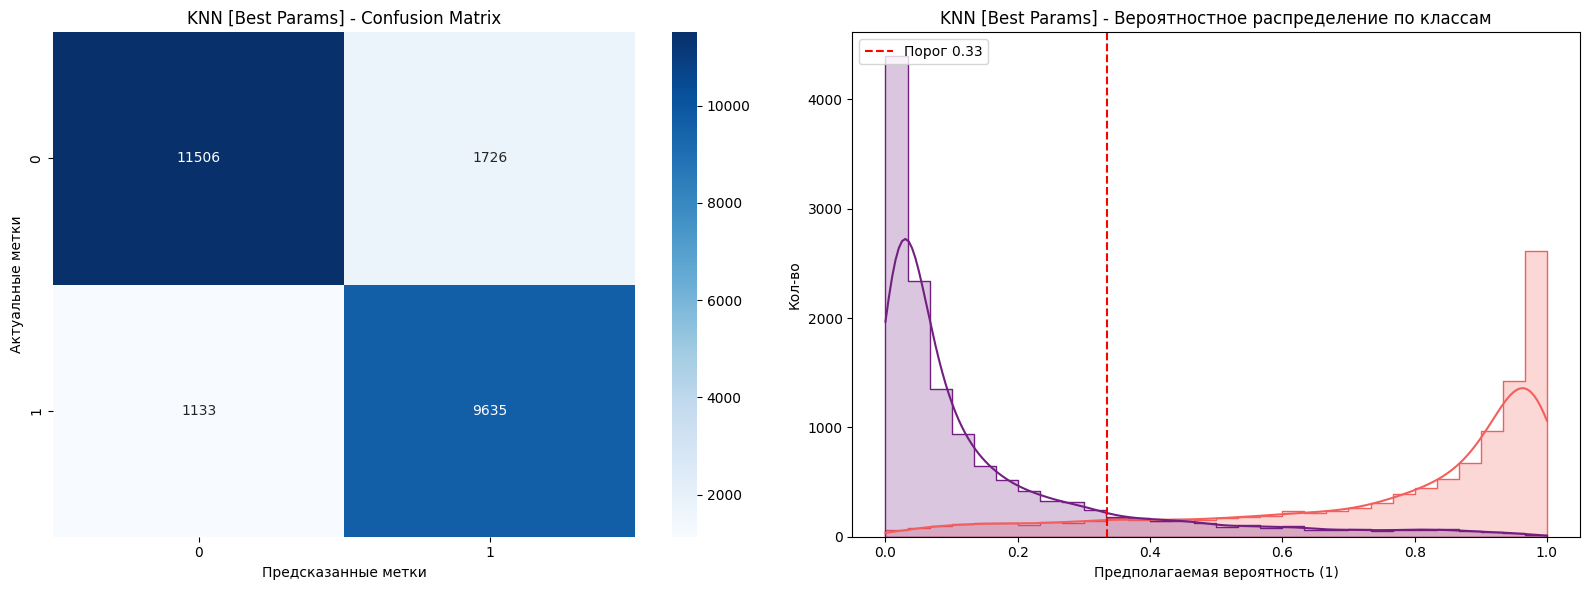

In [ ]:
def build_pipeline_fn(trial):
    params = {
        "n_neighbors": trial.suggest_int("n_neighbors", 1, 500),
        "weights": trial.suggest_categorical("weights", ["uniform", "distance"]),
        "algorithm": trial.suggest_categorical("algorithm", ["auto", "ball_tree", "kd_tree", "brute"]),
        "leaf_size": trial.suggest_int("leaf_size", 10, 200),
        "metric": trial.suggest_categorical(
            "metric",
            ["minkowski", "euclidean", "manhattan"]
        ),
    }

    if params["metric"] == "minkowski":
        params["p"] = trial.suggest_float("p", 1.0, 6.0)

    model = KNeighborsClassifier(**params)
    pipeline = Pipeline(steps=[
        ('preprocessor', StandardScaler()),
        ('model', model)
    ])

    return pipeline

def build_best_pipeline_fn(best_params):
    pipeline = Pipeline(steps=[
        ("preprocessor", StandardScaler()),
        ("model", KNeighborsClassifier(**best_params))
    ])
    return pipeline

run_optuna(build_pipeline_fn, build_best_pipeline_fn, "KNN [Best Params]")

[Tree [Baseline]] ROC-AUC: 0.8214



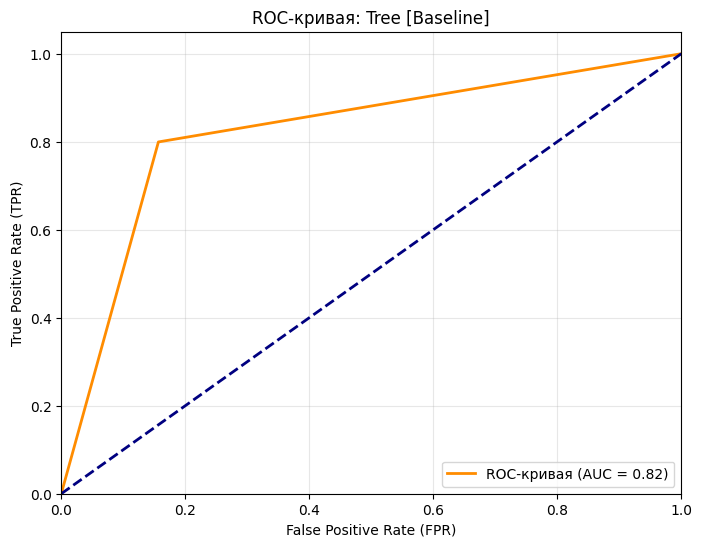


Оптимальный порог: 1.0000
Максимальный F1-score: 0.8027

Результаты на тесте с новым порогом
              precision    recall  f1-score   support

           0       0.84      0.84      0.84     13232
           1       0.81      0.80      0.80     10768

    accuracy                           0.82     24000
   macro avg       0.82      0.82      0.82     24000
weighted avg       0.82      0.82      0.82     24000



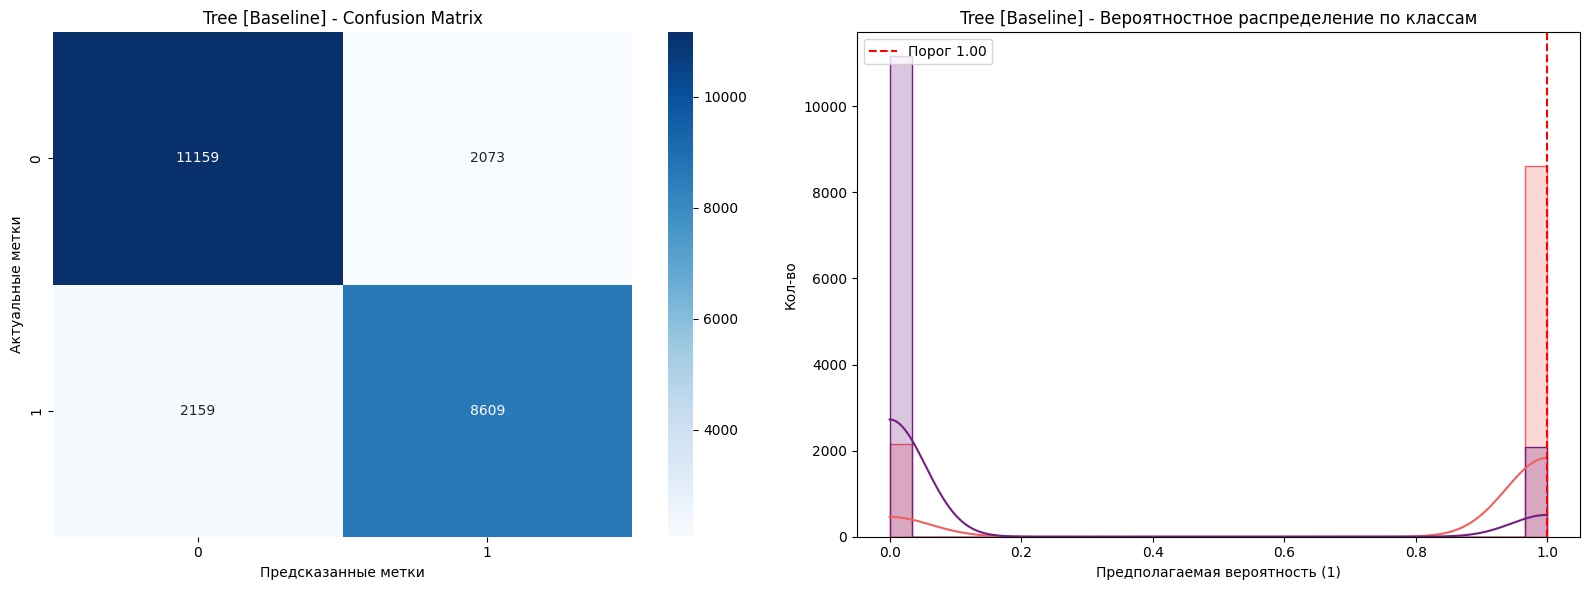

In [ ]:
evaluate_model(DecisionTreeClassifier(class_weight='balanced'), X_train, y_train, name='Tree [Baseline]')

[I 2026-02-14 21:53:12,478] A new study created in memory with name: no-name-0c496c02-0c1d-408b-94e2-0fa7248f1cba


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-02-14 21:53:13,443] Trial 0 finished with value: 0.9383819185344654 and parameters: {'criterion': 'log_loss', 'max_depth': 12, 'min_samples_leaf': 40, 'min_samples_split': 40, 'min_impurity_decrease': 2.2853255256339197e-05, 'ccp_alpha': 1.4347159517201392e-05}. Best is trial 0 with value: 0.9383819185344654.
[I 2026-02-14 21:53:14,246] Trial 1 finished with value: 0.9369488102706931 and parameters: {'criterion': 'entropy', 'max_depth': 12, 'min_samples_leaf': 11, 'min_samples_split': 147, 'min_impurity_decrease': 0.0008231433730995545, 'ccp_alpha': 3.7419406111184946e-05}. Best is trial 0 with value: 0.9383819185344654.
[I 2026-02-14 21:53:15,042] Trial 2 finished with value: 0.9387054161971626 and parameters: {'criterion': 'log_loss', 'max_depth': 7, 'min_samples_leaf': 36, 'min_samples_split': 76, 'min_impurity_decrease': 4.678719265016204e-05, 'ccp_alpha': 0.0004480975918214954}. Best is trial 2 with value: 0.9387054161971626.
[I 2026-02-14 21:53:15,963] Trial 3 finished wi

Лучшие гиперпараметры: {'criterion': 'log_loss', 'max_depth': 8, 'min_samples_leaf': 33, 'min_samples_split': 122, 'min_impurity_decrease': 2.8804169778805483e-05, 'ccp_alpha': 0.0002442886696734996}
Лучшее среднее значение ROC-AUC на кросс-валидации: 0.94
[Tree [Best Params]] ROC-AUC: 0.9399



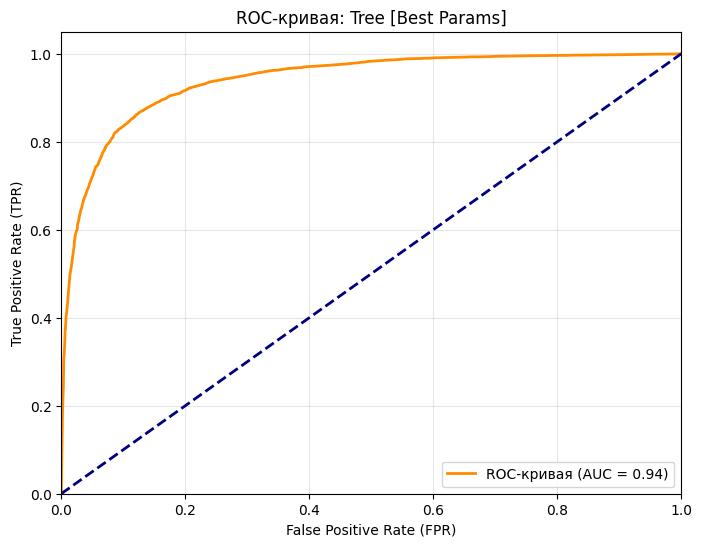


Оптимальный порог: 0.4271
Максимальный F1-score: 0.8574

Результаты на тесте с новым порогом
              precision    recall  f1-score   support

           0       0.89      0.87      0.88     13232
           1       0.85      0.87      0.86     10768

    accuracy                           0.87     24000
   macro avg       0.87      0.87      0.87     24000
weighted avg       0.87      0.87      0.87     24000



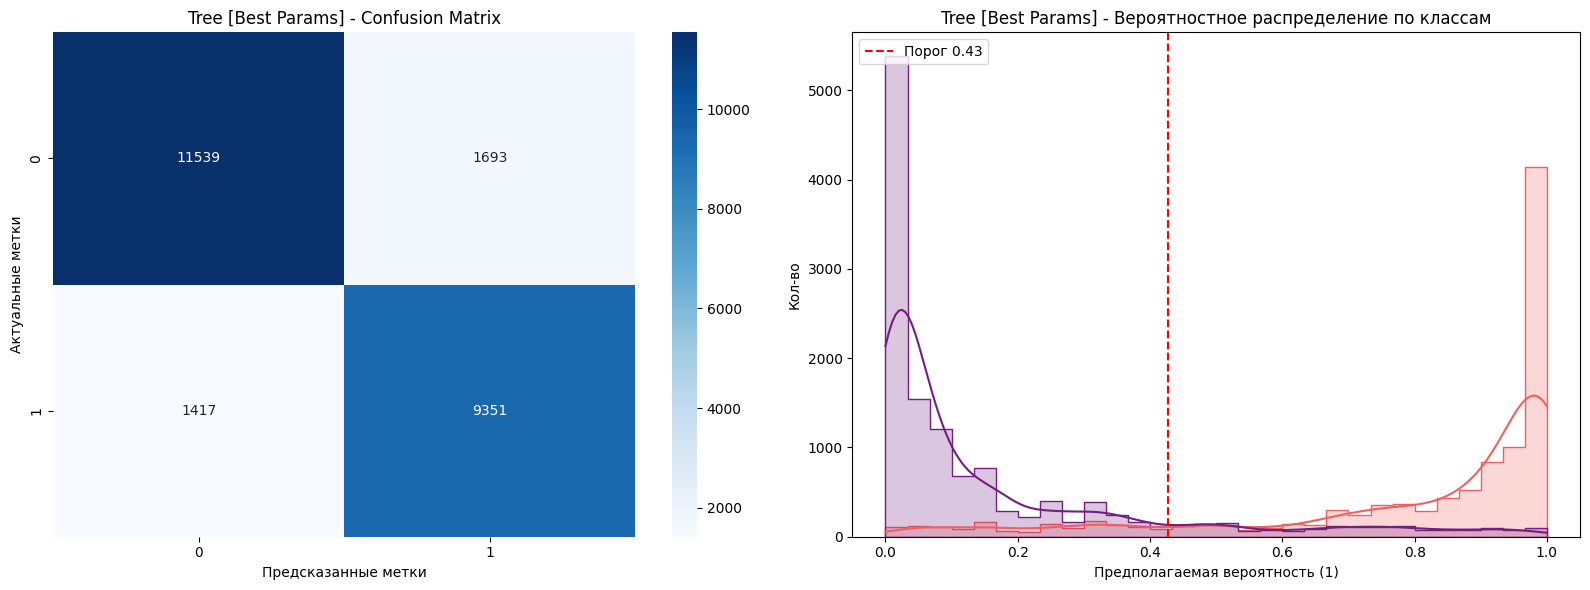

In [ ]:
def build_pipeline_fn(trial):
    params = {
        "criterion": trial.suggest_categorical("criterion", ["entropy", "log_loss"]),
        "splitter": "best",
        "max_depth": trial.suggest_int("max_depth", 4, 15),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 60),
        "min_samples_split": trial.suggest_int("min_samples_split", 20, 150),
        "max_features": None,
        "min_impurity_decrease": trial.suggest_float("min_impurity_decrease", 1e-5, 2e-3, log=True),
        "ccp_alpha": trial.suggest_float("ccp_alpha", 1e-5, 5e-3, log=True),
        "class_weight": "balanced",
        "random_state": RANDOM_STATE,
    }

    return DecisionTreeClassifier(**params)

def build_best_pipeline_fn(best_params):
    return DecisionTreeClassifier(**best_params)

run_optuna(build_pipeline_fn, build_best_pipeline_fn, "Tree [Best Params]")

In [ ]:
pd.DataFrame(results) \
    .sort_values(by='ROC-AUC', ascending=False) \
    .style.background_gradient(cmap='coolwarm')

,Название модели,ROC-AUC
2,LogisticRegression [Best Params],0.952105
0,LogisticRegression [Baseline],0.952104
6,KNN [Best Params],0.950202
11,Tree [Best Params],0.939893
3,LogisticRegression [Best Params with upd pipe],0.938345
1,LogisticRegression [Baseline with upd pipe],0.938330
9,Tree [Best Params],0.934106
4,KNN [Baseline],0.923534
5,KNN [Baseline with upd pipe],0.902542
8,Tree [Best Params],0.852113
